In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import numpy as np
import torch
from torchvision import transforms
import scipy
from DCGANDataset import GANDataLoader
from Cifar_10dataset import CIFAR10FIDDataset
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision.utils as vutils
import torch.backends.cudnn as cudnn
import torch.optim as optim
from torchvision.utils import save_image
from torch.autograd import Variable
import matplotlib.pyplot as plt
import pylab
from dcgan import Discriminator, Generator
from torchvision import models
from torch import nn
from scipy.linalg import sqrtm


In [2]:

#looks like code they used for cifar-XX access
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

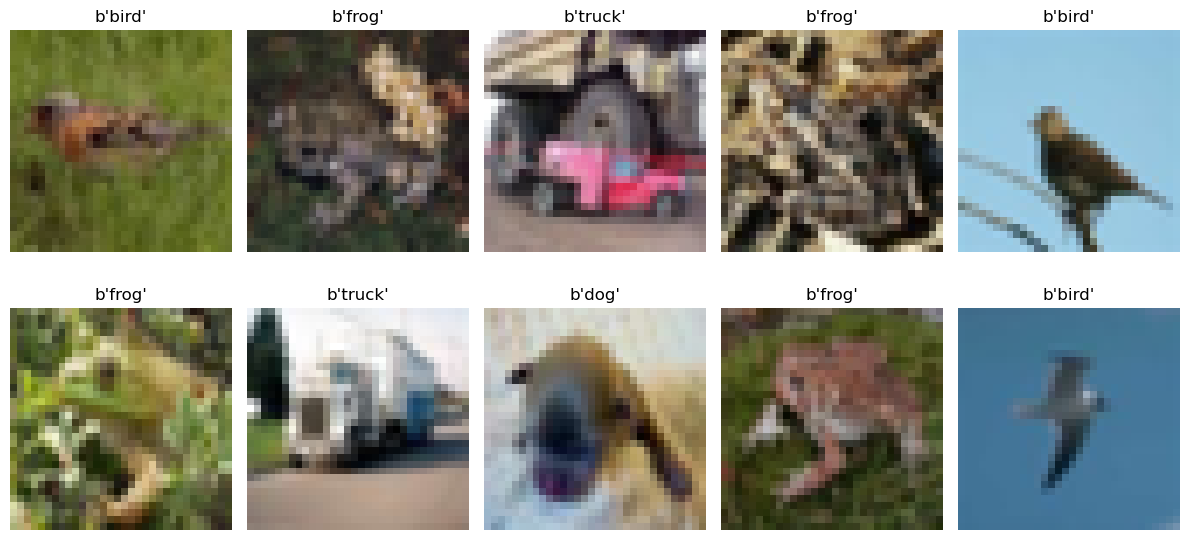

In [3]:
#loading cifar-10 dataset
directory = r"C:\Users\jaime\Documents\Maastricht_work\Master\P5\Semester project\Extra_shits\ImageDataset\cifar-10-python\cifar-10-batches-py\batches.meta"

meta_data = unpickle(directory)

class_names = meta_data[b'label_names']

# 2. Load just the first data batch for visualization
batch1 = unpickle(r"C:\Users\jaime\Documents\Maastricht_work\Master\P5\Semester project\Extra_shits\ImageDataset\cifar-10-python\cifar-10-batches-py\test_batch")
images = batch1[b'data']
labels = batch1[b'labels']

# 3. Reshape the data
# The raw data is a flat array of 3072 numbers (32*32*3)
# It is stored as (Channels, Height, Width) so we reshape then transpose to (H, W, C)
images = images.reshape(len(images), 3, 32, 32).transpose(0, 2, 3, 1)

# 4. Plot 10 random images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(images))
    ax.imshow(images[idx])
    ax.set_title(class_names[labels[idx]])
    ax.axis('off')

plt.tight_layout()
plt.show()


Dataset length: 10000
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 299, 299])
Sample dtype: torch.float32
Sample min: -1.878
Sample max: 2.570
Batch shape: torch.Size([64, 3, 299, 299])
Has NaN: False
Has Inf: False


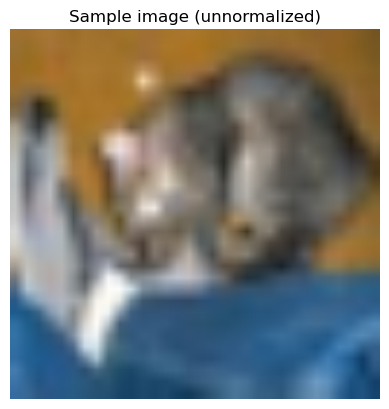

In [4]:
#testing CIFAR-10 dataloader

#transform should be for the inception V3 model
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Quick Tests ---
dataset = CIFAR10FIDDataset(batch1, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)


total_size = len(dataset)
indices = np.random.choice(total_size, 100, replace=False)

subset_Cifar10 = SubsetRandomSampler(indices)
randsubsample = DataLoader(dataset, batch_size=32, sampler=subset_Cifar10)



# 1. Dataset length
print(f"Dataset length: {len(dataset)}")  # expect 10000

# 2. Single sample shape and type
sample = dataset[0]
print(f"Sample type: {type(sample)}")          # <class 'torch.Tensor'>
print(f"Sample shape: {sample.shape}")         # torch.Size([3, 299, 299])
print(f"Sample dtype: {sample.dtype}")         # torch.float32

# 3. Value range after normalization (should be roughly -2.1 to 2.6)
print(f"Sample min: {sample.min():.3f}")
print(f"Sample max: {sample.max():.3f}")

# 4. First DataLoader batch
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")           # torch.Size([64, 3, 299, 299])

# 5. No NaNs or Infs
print(f"Has NaN: {torch.isnan(batch).any()}")  # False
print(f"Has Inf: {torch.isinf(batch).any()}")  # False

# 6. Visual check — show first image unnormalized
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_unnorm = (dataset[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.imshow(img_unnorm)
plt.title("Sample image (unnormalized)")
plt.axis("off")
plt.show()

In [6]:
#load DCGAN
num_gpu = 1 if torch.cuda.is_available() else 0
dira = r"C:\Users\jaime\Documents\Maastricht_work\Master\P5\Semester project\Extra_shits\Weights\netG_epoch_199.pth"

# load the models

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

# load weights
#D.load_state_dict(torch.load(''))
G.load_state_dict(torch.load(dira))
if torch.cuda.is_available():
    D = D.cuda()
    G = G.cuda()


C:\Users\jaime\AppData\Local\Temp\ipykernel_2804\3456221660.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G.load_state_dict(torch.load(dira))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8533859..0.91220766].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8678505..0.9454081].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77323407..0.8894623].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8583515..0.8905418].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.87563485..0.85598564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7903092..0.38558832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9

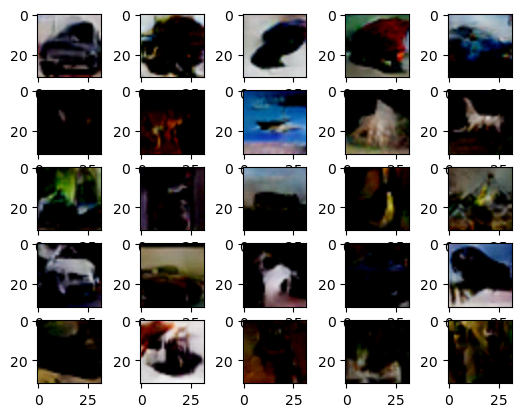

In [ ]:
#testing DCGAN

batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1)
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)


# z = torch.randn(batch_size, latent_size).cuda()
# z = Variable(z)
# fake_images = G(z)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 3, 32, 32)
fake_images_np = fake_images_np.transpose((0, 2, 3, 1))
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.imshow(fake_images_np[i], interpolation='bilinear')
plt.show()


In [8]:
# Source - https://stackoverflow.com/a/51014127
# Posted by M. Deckers, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-02, License - CC BY-SA 4.0

#creating the GAN dataloader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


gen_loader = GANDataLoader(
    generator=G,
    latent_dim=100,
    batch_size=20,#64,
    num_batches= 5,#157,   # 157 * 64 ≈ 10000 to match your real dataset size
    device=device
)
i= 0
for batch in gen_loader:
    # batch is [64, 3, H, W] — pass to Inception for FID
    print(i+1)
    i = i+1 


1
2
3
4
5


In [9]:
#extracting the features in the data using inception v3 model
def extract_features_from_dataloader(dataloader, model, device):
    model.to(device)
    features = []
    
    with torch.no_grad():
        for batch in dataloader:
            # Assuming batch is (images, labels) or just images
            imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
            feat = model(imgs)
            features.append(feat.cpu().numpy())
            
    return np.concatenate(features, axis=0)


In [13]:
#loading inception-V3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#shove the important data with all the matrices of the cifar-10 dataset into a numpy array

incept_model = models.inception_v3(weights='Inception_V3_Weights.IMAGENET1K_V1')

# Set to evaluation mode (important for Batch Normalization and Dropout)
incept_model.eval()

# Remove the final classification layer (Linear layer)
# This ensures the output is the 2048-d feature vector from the pooling layer
incept_model.fc = nn.Identity()
   
# Disable auxiliary logits for inference
incept_model.aux_logits = False

incept_model = incept_model.to(device)



In [14]:
real_processed_feat = extract_features_from_dataloader(randsubsample, incept_model, device)
gen_processed_feat = extract_features_from_dataloader(gen_loader, incept_model, device)

real_mean = np.mean(real_processed_feat, axis = 1)
real_cov = np.cov(real_processed_feat)
gen_mean = np.mean(gen_processed_feat, axis = 1)
gen_cov = np.cov(gen_processed_feat)

In [19]:

def calculate_fid(mu1, sigma1, mu2, sigma2):
    """
    Calculate the Frechet Inception Distance (FID) between two multivariate Gaussians.
    
    Arguments:
    mu1    -- The mean of the features for real images.
    sigma1 -- The covariance matrix of the features for real images.
    mu2    -- The mean of the features for generated images.
    sigma2 -- The covariance matrix of the features for generated images.
    """
    
    # 1. Calculate the squared difference of means
    diff = mu1 - mu2
    # sum of squared differences
    sum_sq_diff = diff.dot(diff)

    # 2. Calculate the square root of the product of covariances
    # sqrt(sigma1 * sigma2)
    covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)

    # 3. Handle potential numerical instability
    # If the product results in complex numbers, check the magnitude of the imaginary part
    if np.iscomplexobj(covmean):
        # The imaginary part should be close to zero if the matrices are symmetric positive semi-definite
        covmean = covmean.real

    # 4. Calculate the trace term: Tr(sigma1 + sigma2 - 2*covmean)
    tr_covmean = np.trace(sigma1 + sigma2 - 2.0 * covmean)

    # 5. Final FID score
    fid = sum_sq_diff + tr_covmean
    
    return fid

In [20]:
print(calculate_fid(real_mean, real_cov, gen_mean, gen_cov))

3.8954308738622045
